# EDA – MNIST Handskrivna Siffror

**Syfte:** Utforska MNIST-datasetet och jämföra tre klassificeringsmodeller — LogisticRegression, RandomForestClassifier och ExtraTreesClassifier — med optimerade hyperparametrar via GridSearchCV.

**Flöde:**
1. Ladda och visualisera rådata
2. Dela upp i tränings- och testset
3. Vi kör en dimensionsreducering och ser vad det ger.
4. Normalisera med StandardScaler
5. Hitta bästa hyperparametrar med GridSearchCV
6. Återträna vinnande modell på full träningsdata
7. Utvärdera på testset med accuracy och confusion matrix

Jag visar sedan en lösning med en Pipeline, men den känns lite svårare att följa.

### Steg 1 – Läs in data och förbered

`fetch_openml` laddar MNIST med 70 000 bilder (28×28 pixlar = 784 features per bild).

Datasetet delas upp i **träning** och **test** med `stratify=y` för att säkerställa jämn fördelning av siffror i båda seten. y är datasetets y.

Därefter normaliseras data med `StandardScaler` — viktigt att den **bara fittas på träningsdata** så att information från testdatan inte läcker in i normaliseringen vid beräkningar av medelvärden mm är med.



Laddar MNIST...


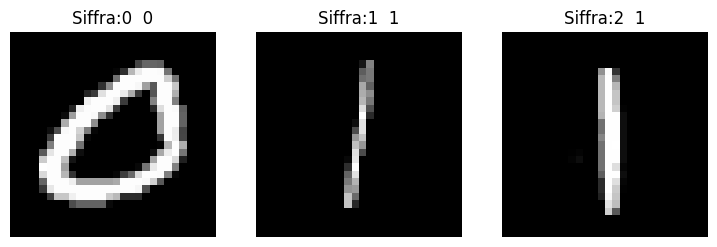

Full träning:       45000 bilder
Validering:         15000 bilder
Test:               10000 bilder
GridSearch-träning: 5000 bilder

**Author**: Yann LeCun, Corinna Cortes, Christopher J.C. Burges  
**Source**: [MNIST Website](http://yann.lecun.com/exdb/mnist/) - Date unknown  
**Please cite**:  

The MNIST database of handwritten digits with 784 features, raw data available at: http://yann.lecun.com/exdb/mnist/. It can be split in a training set of the first 60,000 examples, and a test set of 10,000 examples  

It is a subset of a larger set available from NIST. The digits have been size-normalized and centered in a fixed-size image. It is a good database for people who want to try learning techniques and pattern recognition methods on real-world data while spending minimal efforts on preprocessing and formatting. The original black and white (bilevel) images from NIST were size normalized to fit in a 20x20 pixel box while preserving their aspect ratio. The resulting images contain gre

In [1]:
# Vi importerar alla nödvändiga bibliotek
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix
)
from sklearn.preprocessing import StandardScaler
import time
import warnings
warnings.filterwarnings("ignore")
import seaborn as sns

# ── 1. Ladda rådata (ingen normalisering ännu) ────────────────────────────────
print("Laddar MNIST...")
mnist = fetch_openml('mnist_784', version=1, cache=True, as_frame=False, parser='auto')

X = mnist.data          # råa pixelvärden 0-255
y = mnist.target.astype(int)

# ── 2. Dela upp i träning / validering / test ─────────────────────────────────
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=10_000, random_state=42, stratify=y
)
X_train_full, X_val, y_train_full, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=42, stratify=y_train_val
)

# ── 3. Rita ut några siffror (råa pixlar ger bäst bild) ───────────────────────
plt.figure(figsize=(9, 3))
for i in range(3):
    plt.subplot(1, 3, i + 1)
    plt.imshow(X_train_full[i].reshape(28, 28), cmap='gray')
    plt.title(f"Siffra:{i}  {y_train_full[i]}")
    plt.axis('off')
plt.show()

# ── 4. Normalisera med StandardScaler (fit bara på träningsdata!) ─────────────
scaler = StandardScaler()
X_train_full = scaler.fit_transform(X_train_full)  # fit + transform
X_val        = scaler.transform(X_val)              # bara transform
X_test       = scaler.transform(X_test)             # bara transform

# ── 5. Stratifierat subsampel för GridSearchCV på 5000 bilder ────────────────────────────────
# Stratifierat urval säkerställer jämn fördelning av alla siffror i subsamplet
X_grid_sc, _, y_grid_sc, _ = train_test_split(
    X_train_full, y_train_full, train_size=5000, random_state=42, stratify=y_train_full
)

print(f"Full träning:       {X_train_full.shape[0]} bilder")
print(f"Validering:         {X_val.shape[0]} bilder")
print(f"Test:               {X_test.shape[0]} bilder")
print(f"GridSearch-träning: {X_grid_sc.shape[0]} bilder\n")

print(mnist.DESCR)

> **Notering från DESCR:** Bilderna i MNIST är redan centrerade med masscentrum-metoden. Vid egna prediktioner (t.ex. ritade siffror) behöver man centrera bilden manuellt för bästa resultat. Den ritatde bilden skall också läggas som en 20\*20 bild mitt i en svart 28\*28 bild. Hanterar man inte det funkar det dåligt.

### Steg 2 – PCA: Dimensionsreduktion

Vi vet att det är många pixlar i bilderna som är svarta inte minst ramen då de läggs som 20 * 20 på 28 * 28.

PCA (Principal Component Analysis) reducerar antalet features från 784 (28×28 pixlar) till ett mindre antal **komponenter** som ändå bevarar det mesta av variansen.

Fördelar:
- Snabbare träning och GridSearch
- Minskar risken för overfitting

PCA fittas bara på träningsdata — val/test bara transform (samma princip som StandardScaler).

Antal komponenter (x): 324  (av ursprungliga 784)
Bevarad varians:       95.03%
Test:                  324 pixels per bild 


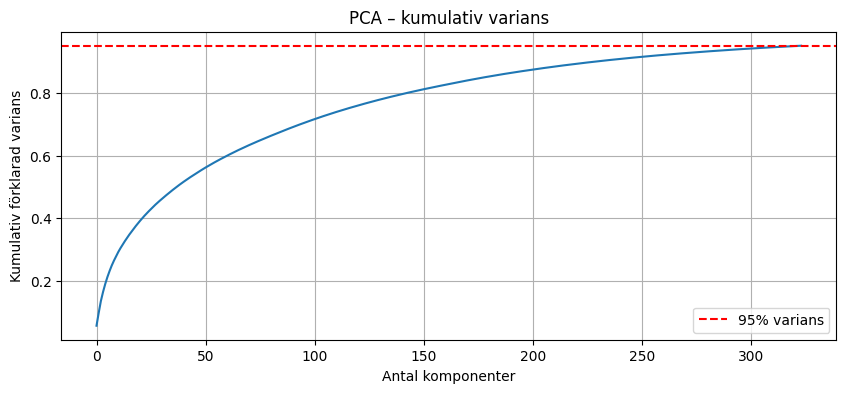

In [2]:
from sklearn.decomposition import PCA

# Fit PCA på träningsdata — väljer antal komponenter som bevarar 95% av variansen
pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_full)   # fit + transform då den lär sig hur datan är uppbyggd
X_val_pca   = pca.transform(X_val)              # bara transform
X_test_pca  = pca.transform(X_test)             # bara transform
X_grid_pca  = pca.transform(X_grid_sc)          # bara transform

n_components = pca.n_components_
explained    = pca.explained_variance_ratio_.sum()

print(f"Antal komponenter (x): {n_components}  (av ursprungliga 784)")
print(f"Bevarad varians:       {explained:.2%}")
print(f"Test:                  {X_train_pca.shape[1]} pixels per bild ")

# Visa hur mycket varians varje komponent bidrar med
plt.figure(figsize=(10, 4))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.axhline(0.95, color='red', linestyle='--', label='95% varians')
plt.xlabel('Antal komponenter')
plt.ylabel('Kumulativ förklarad varians')
plt.title('PCA – kumulativ varians')
plt.legend()
plt.grid(True)
plt.show()

### Steg 3 – Balansen av klasser

Kontrollerar att datasetet är **balanserat** — alltså att alla siffror (0–9) förekommer ungefär lika ofta. Ett obalanserat dataset kan lura modellen att bli bra på vanliga klasser men dålig på ovanliga.

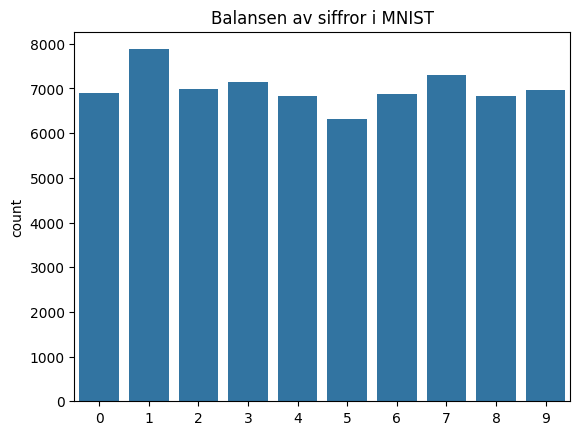

In [18]:
sns.countplot(x=mnist.target.astype(int))
plt.title("Balansen av siffror i MNIST")
plt.show()

### Steg 4 – Statistik om pixelvärdena

Min, max och medelvärde på träningsdatan efter normalisering. Medelvärdet är lågt eftersom de flesta pixlar är svarta (bakgrund) — inte så konstigt. Inga null värden i X-datan heller.

In [3]:
print(f"Min-värde:  {X_train_full.min()}")
print(f"Max-värde:  {X_train_full.max()}")
print(f"Medelvärde: {X_train_full.mean():.2f}")
print(f"Antal NaN:  {np.isnan(X_train_full).sum()}")

Min-värde:  -1.2830277465255435
Max-värde:  212.12967732061915
Medelvärde: -0.00
Antal NaN:  0


### Steg 5 – GridSearchCV: hitta bästa hyperparametrar

Definierar **parameternät** för tre modeller och en gemensam hjälpfunktion `run_grid_search`.

`GridSearchCV` med `cv=5` testar alla kombinationer av parametrar via 5-faldig korsvalidering på ett **subsampel** (`X_grid_sc`, 5 000 bilder) av träningsdatan — annars tar det för lång tid med den dator jag har. Kombinationerna sker av antal värden per hyperparameter.


| Modell | Antal kombinationer |
|--------|-------------------|
| LogisticRegression | 4 × 2 = 8 |
| RandomForestClassifier | 2 × 3 × 2 x 2 = 24 |
| ExtraTreesClassifier | 2 × 3 × 2 x 2 = 24 |

In [4]:
# --- LogisticRegression ---
param_grid_lr = {
    "C":   [0.01, 0.1, 1.0, 10.0],
    "tol": [0.01, 0.1],
}

# --- RandomForestClassifier ---
param_grid_rf = {
    "n_estimators":      [100, 200],
    "max_depth":         [None, 20, 40],
    "min_samples_split": [2, 5],
    "max_features":      ["sqrt", "log2"],
}

# --- ExtraTreesClassifier ---
param_grid_et = {
    "n_estimators":      [100, 200],
    "max_depth":         [None, 20, 40],
    "min_samples_split": [2, 5],
    "max_features":      ["sqrt", "log2"],
}

def run_grid_search(name, estimator, param_grid, X_gs, y_gs):
    print(f"\n{'='*55}")
    print(f"  GridSearchCV: {name}")
    print(f"{'='*55}")
    t0 = time.time()
    gs = GridSearchCV(
        estimator, param_grid,
        cv=5, scoring="accuracy",
        n_jobs=-1,
        verbose=1,
        refit=True
    )
    gs.fit(X_gs, y_gs)
    elapsed = time.time() - t0
    print(f"  Bästa params:  {gs.best_params_}")
    print(f"  CV-accuracy:   {gs.best_score_:.4f}")
    print(f"  Tid:           {elapsed:.1f}s")
    return gs

### Steg 6 – Kör GridSearch för alla tre modeller, först med dimensionsreducering, sedan utan

`run_grid_search` anropas för varje modell. Resultatet — bästa parametrar och CV-accuracy — skrivs ut för varje. Vi börjar med de dataset vig gjort dimensionsreducering på.

In [5]:
# LogisticRegression med PCA data setet
grid_sc_lr = run_grid_search("LogisticRegression med PCA",
    LogisticRegression(max_iter=1000, solver="saga"), param_grid_lr, X_grid_pca, y_grid_sc)

# RandomForest med PCA data setet
grid_sc_rf = run_grid_search("RandomForestClassifier med PCA",
    RandomForestClassifier(random_state=42, n_jobs=-1), param_grid_rf, X_grid_pca, y_grid_sc)

# ExtraTrees med PCA data setet
grid_sc_et = run_grid_search("ExtraTreesClassifier med PCA",
    ExtraTreesClassifier(random_state=42, n_jobs=-1), param_grid_et, X_grid_pca, y_grid_sc)


  GridSearchCV: LogisticRegression med PCA
Fitting 5 folds for each of 8 candidates, totalling 40 fits
  Bästa params:  {'C': 1.0, 'tol': 0.01}
  CV-accuracy:   0.8736
  Tid:           7.0s

  GridSearchCV: RandomForestClassifier med PCA
Fitting 5 folds for each of 24 candidates, totalling 120 fits
  Bästa params:  {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 200}
  CV-accuracy:   0.8938
  Tid:           44.9s

  GridSearchCV: ExtraTreesClassifier med PCA
Fitting 5 folds for each of 24 candidates, totalling 120 fits
  Bästa params:  {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 200}
  CV-accuracy:   0.8894
  Tid:           17.5s


Nu kör vi dataset utan PCA, RAW data

In [6]:


# LogisticRegression
grid_sc_lr = run_grid_search("LogisticRegression RAW data",
    LogisticRegression(max_iter=1000, solver="saga"), param_grid_lr, X_grid_sc, y_grid_sc)

# RandomForest
grid_sc_rf = run_grid_search("RandomForestClassifier RAW data",
    RandomForestClassifier(random_state=42, n_jobs=-1), param_grid_rf, X_grid_sc, y_grid_sc)

# ExtraTrees
grid_sc_et = run_grid_search("ExtraTreesClassifier RAW data",
    ExtraTreesClassifier(random_state=42, n_jobs=-1), param_grid_et, X_grid_sc, y_grid_sc)





  GridSearchCV: LogisticRegression RAW data
Fitting 5 folds for each of 8 candidates, totalling 40 fits
  Bästa params:  {'C': 10.0, 'tol': 0.01}
  CV-accuracy:   0.8806
  Tid:           11.9s

  GridSearchCV: RandomForestClassifier RAW data
Fitting 5 folds for each of 24 candidates, totalling 120 fits
  Bästa params:  {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 100}
  CV-accuracy:   0.9364
  Tid:           18.6s

  GridSearchCV: ExtraTreesClassifier RAW data
Fitting 5 folds for each of 24 candidates, totalling 120 fits
  Bästa params:  {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 200}
  CV-accuracy:   0.9422
  Tid:           20.7s


### Varför tar RandomForestClassifier så mycket längre tid med PCA än utan? AI svara så här:
GridSearch testar ALLA 24 kombinationer, inklusive max_depth=None (obegränsat djup).

Med raw data (784 features):
Många pixlar är nära noll för de flesta bilder. RF hittar snabbt att dessa pixlar inte kan dela upp data meningsfullt → träden slutar växa tidigt i praktiken, även med max_depth=None.

Med PCA (154 features):
PCA tar bort all noll-varians — alla 324 komponenter är informativa. Med max_depth=None kan RF-träden växa mycket djupare, och RF måste söka optimala trösklar på varje nod i varje djupare träd.


RF  raw  + max_depth=None → träd stannar ~djup 15 (tomma pixlar stoppar)
RF  PCA  + max_depth=None → träd växer till djup 30+ (alla features aktiva)
ExtraTrees drabbas inte lika hårt för att den väljer trösklar slumpmässigt — djupare träd kostar inte lika mycket extra.

Det är alltså kombinationen RF + PCA + max_depth=None som driver upp PCA-körningen till 44.8s. En kombination som råkar testas 5 folds × 2 n_estimators × 5 folds = 10 av de 120 totala fits, men som var och en är väsentligt tyngre.





### Steg 7 – Återträna på full träningsdata och jämför på valideringsset

GridSearch kördes på ett subsampel (5 000 bilder). Nu återtränas varje modell med bästa parametrar på **hela träningsdatan** och utvärderas på **valideringssettet** (`X_val`) för att välja vinnare.

`X_test` sparas till sista steget och används **bara en gång** mot den utvalda modellen.

In [10]:
# Jämför modellerna på valideringssettet — X_test rörs inte här!
def evaluate_on_val(name, gs, X_train, y_train, X_val, y_val):
    print(f"\nÅtertränar {name} med bästa params på full träningsdata...")
    t0 = time.time()
    best = gs.best_estimator_
    best.fit(X_train, y_train)
    train_time = time.time() - t0
    acc = accuracy_score(y_val, best.predict(X_val))
    print(f"  Val accuracy: {acc:.6f}  (träntid: {train_time:.1f}s)")

evaluate_on_val("LogisticRegression",     grid_sc_lr, X_train_full, y_train_full, X_val, y_val)
evaluate_on_val("RandomForestClassifier", grid_sc_rf, X_train_full, y_train_full, X_val, y_val)
evaluate_on_val("ExtraTreesClassifier",   grid_sc_et, X_train_full, y_train_full, X_val, y_val)


Återtränar LogisticRegression med bästa params på full träningsdata...
  Val accuracy: 0.910133  (träntid: 27.1s)

Återtränar RandomForestClassifier med bästa params på full träningsdata...
  Val accuracy: 0.967667  (träntid: 3.3s)

Återtränar ExtraTreesClassifier med bästa params på full träningsdata...
  Val accuracy: 0.972867  (träntid: 10.8s)


### Steg 8 – Vinnare: ExtraTreesClassifier → slutlig utvärdering på testset

ExtraTreesClassifier presterade bäst på valideringssettet. Nu används `X_test` för första och enda gången för att ge en opartisk slutlig bedömning av modellen.

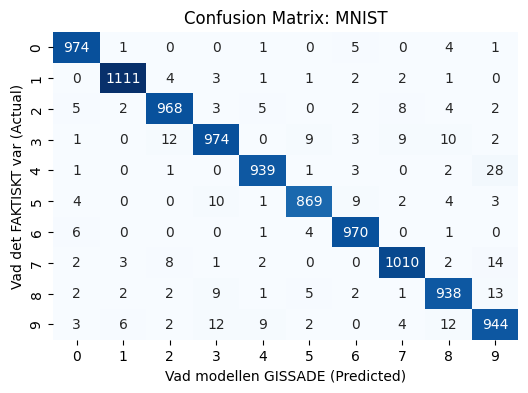

In [8]:
# Låt modellen gissa på hela testsetet
y_pred = grid_sc_et.predict(X_test)

# Skapa själva matrisen
cm = confusion_matrix(y_test, y_pred)

# Rita upp den snyggt med Seaborn
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Vad modellen GISSADE (Predicted)')
plt.ylabel('Vad det FAKTISKT var (Actual)')
plt.title('Confusion Matrix: MNIST')
plt.show()

### Steg 9 – Vidare mot StreamLit
 Med EDA:n ovan känns det som om vi fått en bra känsla för MNIST datasetet och tar med oss detta resultat till appen vi byggt i Streamlit.

### Pipeline-version — StandardScaler inuti GridSearch

Den här är inte inkluderad i EDA:n, men eftersom jag började projektet med att arbeta så tänkte jag bara visa att jag fick ihop det med. Här körs allt i en Pipeline per modell. Även om den koden är mer slimmad så tycker jag att läsbarheten ovan är bättre. Man ser också att accurancy-värdena skiljer sig. Antalet rader i dataseten här är ju annorlunda mot ovan samt att de  innehåller olika bilder. Men det är ingen större skillnad på värdena direkt.

In [9]:
from sklearn.pipeline import Pipeline

# Återskapa oskalad datasplit (samma random_state som cell 1 → identiska index)
# Pipeline sköter skalningen internt, så vi behöver rådata här
X_temp, X_test_raw, y_temp, kasserad         = train_test_split(X, y, test_size=10_000, random_state=42, stratify=y)
X_train_raw, X_val_raw, kasserad, y_val_raw  = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)
X_search_raw, kasserad, y_search_raw, kasserad = train_test_split(X_train_raw, y_train_full, train_size=5000, random_state=42, stratify=y_train_full)

# Parameternät — prefix "clf__" krävs eftersom parametrarna tillhör modellen i pipelinen
params_lr = {"clf__C": [0.01, 0.1, 1.0, 10.0], "clf__tol": [0.01, 0.1]}
params_rf = {"clf__n_estimators": [100, 200], "clf__max_depth": [None, 20, 40], "clf__min_samples_split": [2, 5], "clf__max_features": ["sqrt", "log2"]}
params_et = {"clf__n_estimators": [100, 200], "clf__max_depth": [None, 20, 40], "clf__min_samples_split": [2, 5], "clf__max_features": ["sqrt", "log2"]}

def run_pipeline_search(name, model, params):
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("clf",    model)
    ])
    print(f"\n{'='*55}\n  Pipeline GridSearchCV: {name}\n{'='*55}")
    t0 = time.time()
    gs = GridSearchCV(pipe, params, cv=5, scoring="accuracy", n_jobs=-1, verbose=1, refit=True)
    gs.fit(X_search_raw, y_search_raw)
    print(f"  Bästa params:  {gs.best_params_}")
    print(f"  CV-accuracy:   {gs.best_score_:.4f}  ({time.time()-t0:.1f}s)")
    gs.best_estimator_.fit(X_train_raw, y_train_full)
    acc = accuracy_score(y_val_raw, gs.best_estimator_.predict(X_val_raw))
    print(f"  Val accuracy:  {acc:.4f}")

run_pipeline_search("LogisticRegression",     LogisticRegression(max_iter=1000, solver="saga"), params_lr)
run_pipeline_search("RandomForestClassifier", RandomForestClassifier(random_state=42, n_jobs=-1), params_rf)
run_pipeline_search("ExtraTreesClassifier",   ExtraTreesClassifier(random_state=42, n_jobs=-1),  params_et)


  Pipeline GridSearchCV: LogisticRegression
Fitting 5 folds for each of 8 candidates, totalling 40 fits
  Bästa params:  {'clf__C': 10.0, 'clf__tol': 0.01}
  CV-accuracy:   0.8918  (11.7s)
  Val accuracy:  0.9100

  Pipeline GridSearchCV: RandomForestClassifier
Fitting 5 folds for each of 24 candidates, totalling 120 fits
  Bästa params:  {'clf__max_depth': 20, 'clf__max_features': 'sqrt', 'clf__min_samples_split': 5, 'clf__n_estimators': 100}
  CV-accuracy:   0.9366  (19.8s)
  Val accuracy:  0.9677

  Pipeline GridSearchCV: ExtraTreesClassifier
Fitting 5 folds for each of 24 candidates, totalling 120 fits
  Bästa params:  {'clf__max_depth': None, 'clf__max_features': 'sqrt', 'clf__min_samples_split': 2, 'clf__n_estimators': 200}
  CV-accuracy:   0.9422  (23.6s)
  Val accuracy:  0.9729
